# California Multi-Temporal Remote Sensing Change Detection for Vegetation Stress Monitoring

## Objective
This notebook analyzes multi-temporal vegetation index data in California and explores whether abnormal vegetation stress periods can be detected through time series analysis.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Generate Simulated Vegetation Index Time Series

In [3]:
# Set random seed for reproducibility
np.random.seed(42)

# Create a monthly date range
dates = pd.date_range(start="2018-01-01", end="2024-12-31", freq="ME")

# Create a seasonal vegetation signal
seasonal_pattern = 0.15 * np.sin(2 * np.pi * np.arange(len(dates)) / 12)

# Create a slowly changing baseline
baseline = 0.6 + 0.01 * np.linspace(0, 1, len(dates))

# Add random noise
noise = np.random.normal(0, 0.03, len(dates))

# Simulate vegetation index
ndvi = baseline + seasonal_pattern + noise

# Introduce an abnormal stress period
stress_start = 45
stress_end = 52
ndvi[stress_start:stress_end] -= 0.18

# Create DataFrame
df = pd.DataFrame({
    "date": dates,
    "ndvi": ndvi
})

df.head()

,date,ndvi
0,2018-01-31,0.614901
1,2018-02-28,0.670973
2,2018-03-31,0.749575
3,2018-04-30,0.796052
4,2018-05-31,0.723361


## Visualize the Time Series

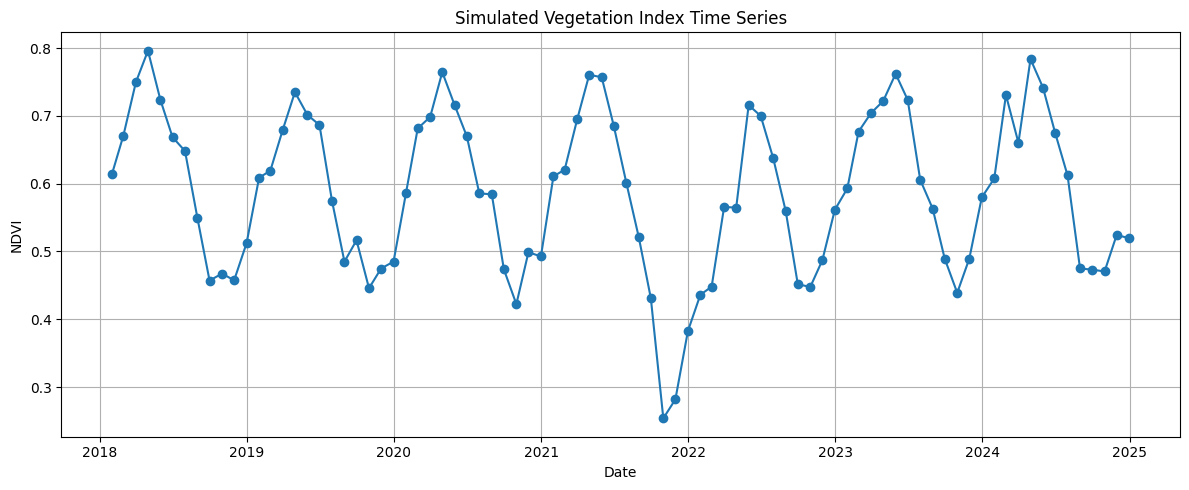

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["ndvi"], marker="o", linewidth=1.5)
plt.title("Simulated Vegetation Index Time Series")
plt.xlabel("Date")
plt.ylabel("NDVI")
plt.grid(True)
plt.tight_layout()
plt.savefig("../figures/simulated_ndvi_timeseries.png", dpi=300)
plt.show()

## Rolling Mean for Trend Smoothing

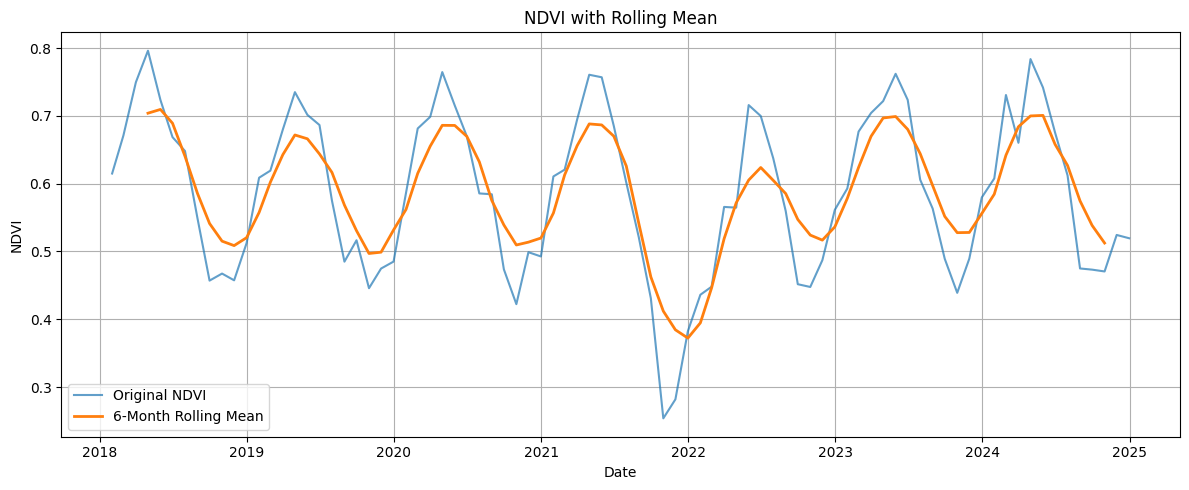

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["ndvi"], label="Original NDVI", alpha=0.7)
plt.plot(df["date"], df["rolling_mean"], label="6-Month Rolling Mean", linewidth=2)
plt.title("NDVI with Rolling Mean")
plt.xlabel("Date")
plt.ylabel("NDVI")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("../figures/ndvi_rolling_mean.png", dpi=300)
plt.show()

## Anomaly Detection with Z-Score

In [12]:
mean_ndvi = df["ndvi"].mean()
std_ndvi = df["ndvi"].std()

df["z_score"] = (df["ndvi"] - mean_ndvi) / std_ndvi

df.head()

,date,ndvi,rolling_mean,z_score,stress_flag
0,2018-01-31,0.614901,NaN,0.236694,False
1,2018-02-28,0.670973,NaN,0.709872,False
2,2018-03-31,0.749575,NaN,1.373195,False
3,2018-04-30,0.796052,0.703907,1.765409,False
4,2018-05-31,0.723361,0.709440,1.151975,False


In [13]:
threshold = -1.5
df["stress_flag"] = df["z_score"] < threshold

df[df["stress_flag"]]

,date,ndvi,rolling_mean,z_score,stress_flag
45,2021-10-31,0.253826,0.411967,-2.810384,True
46,2021-11-30,0.281819,0.384384,-2.574155,True
47,2021-12-31,0.382376,0.372195,-1.725564,True


## Highlight Detected Stress Periods

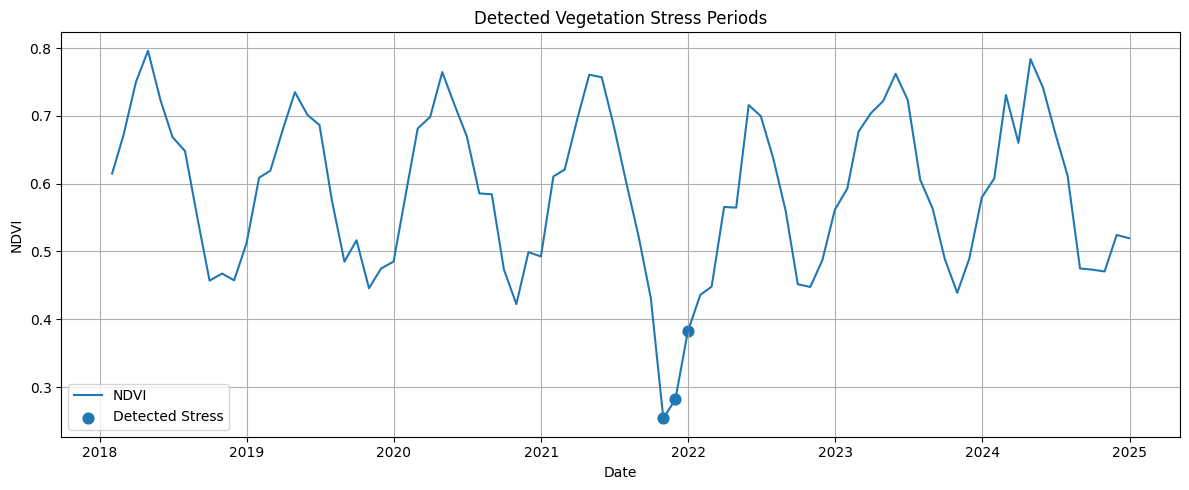

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["ndvi"], label="NDVI", linewidth=1.5)
plt.scatter(
    df.loc[df["stress_flag"], "date"],
    df.loc[df["stress_flag"], "ndvi"],
    label="Detected Stress",
    s=60
)
plt.title("Detected Vegetation Stress Periods")
plt.xlabel("Date")
plt.ylabel("NDVI")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("../figures/detected_stress_periods.png", dpi=300)
plt.show()

## Initial Interpretation

The simulated vegetation index series shows clear seasonal variation, moderate noise, and an abnormal stress period.  
Using a simple z-score threshold, several low-value observations were flagged as potential vegetation stress events.  
This demonstrates a basic workflow for change detection in multi-temporal environmental data.

## Save Figures

## Summary

In this first prototype, I created a simulated multi-temporal vegetation index time series to test a basic environmental change detection workflow.  
The analysis included trend visualization, rolling mean smoothing, and anomaly detection using z-scores.  
Several low-value observations were successfully flagged as potential vegetation stress periods.  

This prototype establishes the core analytical framework for the project.  
The next step is to replace the simulated series with real California remote sensing vegetation data and evaluate whether the same workflow can detect meaningful environmental stress patterns.

## Load NDVI Data from CSV

In [16]:
real_df = pd.read_csv("../data/california_ndvi_sample.csv")
real_df["date"] = pd.to_datetime(real_df["date"])
real_df.head()

,date,ndvi
0,2018-01-31,0.58
1,2018-02-28,0.60
2,2018-03-31,0.64
3,2018-04-30,0.69
4,2018-05-31,0.72
